# CreditLens — 06 · Drift monitoring (PSI)

Production credit models degrade when the live applicant population drifts from the training population.
We track this with the **Population Stability Index (PSI)** per feature:

$$\mathrm{PSI}=\sum_\text{bins}(p_\text{new}-p_\text{ref})\,\ln\frac{p_\text{new}}{p_\text{ref}}$$

Convention: **<0.1** stable · **0.1–0.2** moderate · **>0.2** significant (flag). The reference distribution
(quantile bins + a NaN bucket per feature) is captured at train time in `models/reference.json` and is the
same one `/batch_predict` uses to score uploads.

In [1]:
import sys; sys.path.insert(0, "..")
import json
import pandas as pd
import matplotlib.pyplot as plt

from creditlens.config import MODELS_DIR
from creditlens.data.features import MODEL_FEATURES, load_or_build_model_matrix
from creditlens.evaluation.drift import drift_report

reference = json.loads((MODELS_DIR / "reference.json").read_text())
mat = load_or_build_model_matrix().sample(5000, random_state=0)
print("reference features:", len(reference), "| sample rows:", len(mat))

reference features: 15 | sample rows: 5000


## No drift vs an injected shift
Score the held-out sample against the reference (should be stable), then shift two features to simulate a changed applicant pool.

In [2]:
clean = drift_report(reference, mat, MODEL_FEATURES)

shifted = mat.copy()
shifted["age"] = shifted["age"] + 15                  # older applicant pool
shifted["credit_to_income"] = shifted["credit_to_income"] * 1.8  # larger loans
drifted = drift_report(reference, shifted, MODEL_FEATURES)

print("clean   -> max PSI:", clean["max_psi"], "| flagged:", clean["flagged"])
print("shifted -> max PSI:", drifted["max_psi"], "| flagged:", drifted["flagged"])

clean   -> max PSI: 0.0026 | flagged: []
shifted -> max PSI: 4.048 | flagged: ['credit_to_income', 'age']


## PSI by feature (shifted batch)

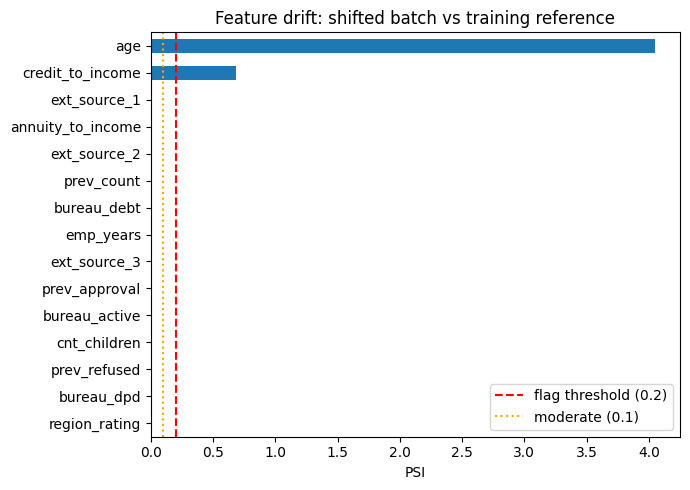

In [3]:
psi = pd.Series(drifted["per_feature"]).sort_values()
ax = psi.plot.barh(figsize=(7, 5))
ax.axvline(0.2, color="red", ls="--", label="flag threshold (0.2)")
ax.axvline(0.1, color="orange", ls=":", label="moderate (0.1)")
ax.set_xlabel("PSI")
ax.legend()
ax.set_title("Feature drift: shifted batch vs training reference")
plt.tight_layout()

## Findings

Drift is monitored with **PSI** against the training reference captured at train time
(`models/reference.json`) — the same reference `/batch_predict` uses on every upload.

- **No drift:** scoring a fresh sample from the training distribution gives **max PSI ≈ 0.003**, nothing flagged — the reference bins (NaN bucket + deduped quantile edges) are stable.
- **Injected shift:** raising `age` by 15y and scaling `credit_to_income` ×1.8 flags **exactly those two features** with **PSI ≫ 0.2**; the rest stay quiet.
- **In production:** PSI > 0.2 on any feature signals population shift → investigate / retrain. Per-feature PSI ships in every `/batch_predict` response under `summary.drift`.